In [1]:
import os 
from pathlib import Path
import numpy as np
import glob
os.chdir(Path('/home/globc/garcia/'))

from scenarIA.src.utils.plotutils import plot_mean_std_simulations
from scenarIA.src.utils.settings import DATASET_DIR, GRAPHS_DIR


In [2]:
colors_dict = {'historical':'k',
               'ssp119': 'orange',
              'ssp126': 'green', 
              'ssp245': 'b', 
              'ssp370':'r', 
              'ssp585': 'mediumorchid'}
labels = ['historical', 'ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp585']
vmin = {'tas': 285, 'pr': 2.75}
vmax = {'tas': 293, 'pr': 3.25}

/softs/Anaconda/2024.02-1/envs/gloenv_py3.11/lib/python3.12/site-packages/pyproj/__init__.py:91: UserWarning: Valid PROJ data directory not found. Either set the path using the environmental variable PROJ_DATA (PROJ 9.1+) | PROJ_LIB (PROJ<9.1) or with `pyproj.datadir.set_data_dir`.
  warnings.warn(str(err))


<xarray.DataArray 'tas' (time: 165, member: 50)> Size: 66kB
array([[286.62673086, 286.53815005, 286.77751233, ..., 286.66448683,
        286.7961876 , 286.5765182 ],
       [286.60913576, 286.55907268, 286.71671074, ..., 286.5569033 ,
        286.77914868, 286.63099235],
       [286.61609651, 286.50430308, 286.55745638, ..., 286.63773738,
        286.54144554, 286.61578322],
       ...,
       [287.65400302, 287.75127445, 287.73726394, ..., 287.89878214,
        287.61918473, 287.59186885],
       [287.5681607 , 287.88207643, 287.7372011 , ..., 287.58352357,
        287.67170876, 287.61733806],
       [287.63072443, 287.82959506, 287.80784281, ..., 287.61134716,
        287.88738447, 287.69959363]])
Coordinates:
  * time     (time) datetime64[ns] 1kB 1850-01-01 1851-01-01 ... 2014-01-01
Dimensions without coordinates: member
<xarray.DataArray 'tas' (time: 86, member: 50)> Size: 34kB
array([[287.64538905, 287.62861634, 287.58180399, ..., 287.78119838,
        287.89829147, 287.75481336]

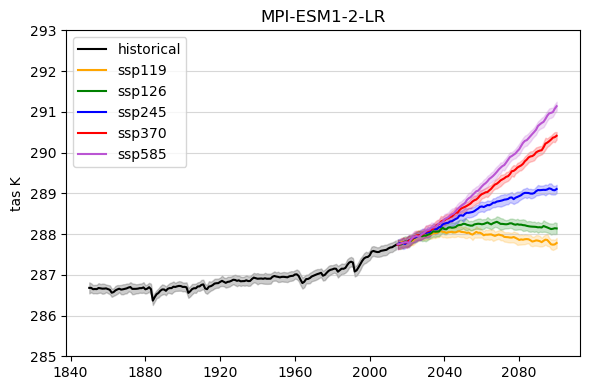

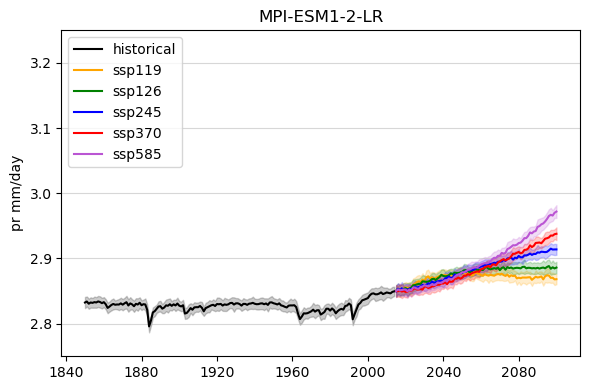

In [3]:

root_dir = DATASET_DIR / 'MPI-ESM1-2-LR/annual/'
files_dict = {}
for simu in labels:
    files_dict[simu] = root_dir / f'outputs_{simu}.nc'

for var in ['tas', 'pr']:
    plot_mean_std_simulations(files_dict,
                              var_name=var,
                              colors_dict = colors_dict,
                              title='MPI-ESM1-2-LR',
                              vmin=vmin[var],
                              vmax=vmax[var],
                              save_path=root_dir / f'MPI-ESM1-2-LR_{var}_temporal_evolution.png'
                              )

In [3]:
labels = ['historical', 'ssp126', 'ssp245', 'ssp370', 'ssp585']
colors_dict = {'historical':'k',
              'ssp126': 'green', 
              'ssp245': 'b', 
              'ssp370':'r', 
              'ssp585': 'mediumorchid'}
root_dir = Path('/scratch/globc/garcia/common_data/CNRM-CM6-1/')


<xarray.DataArray 'tas' (time: 165, member: 30)> Size: 40kB
dask.array<truediv, shape=(165, 30), dtype=float64, chunksize=(1, 30), chunktype=numpy.ndarray>
Coordinates:
    height   float64 8B 2.0
  * member   (member) int64 240B 0 1 2 3 4 5 6 7 8 ... 22 23 24 25 26 27 28 29
  * time     (time) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
<xarray.DataArray 'tas' (time: 25, member: 30)> Size: 6kB
dask.array<truediv, shape=(25, 30), dtype=float64, chunksize=(1, 30), chunktype=numpy.ndarray>
Coordinates:
    height   float64 8B 2.0
  * member   (member) int64 240B 0 1 2 3 4 5 6 7 8 9 ... 20 21 22 23 0 1 2 3 4 5
  * time     (time) int64 200B 2015 2016 2017 2018 2019 ... 2036 2037 2038 2039
<xarray.DataArray 'tas' (time: 61, member: 6)> Size: 3kB
dask.array<truediv, shape=(61, 6), dtype=float64, chunksize=(1, 6), chunktype=numpy.ndarray>
Coordinates:
    height   float64 8B 2.0
  * member   (member) int64 48B 0 1 2 3 4 5
  * time     (time) int64 488B 2040 2041 2042 2043 2044

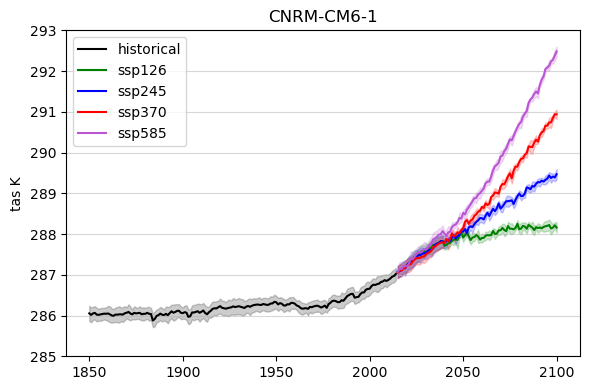

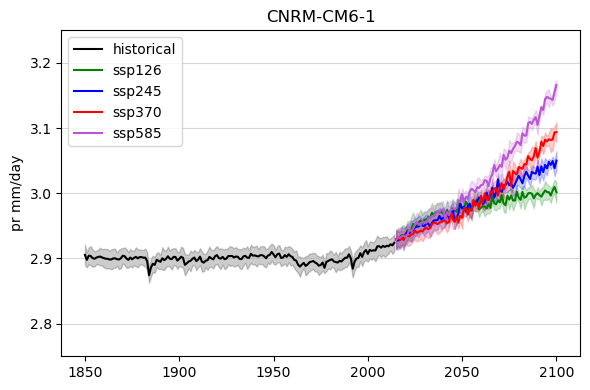

In [6]:
files_dict = {}

for var in ['tas', 'pr']:

    for exp in labels:
        if exp.startswith('ssp'):
            exp_paths = np.sort(glob.glob(str(f'/scratch/globc/garcia/common_data/CNRM-CM6-1/{exp}/{var}*reformat*.nc')))
        else:   
            exp_paths = glob.glob(str(f'/scratch/globc/garcia/common_data/CNRM-CM6-1/{exp}/{var}*185001-201412.nc'))
        files_dict[exp] = exp_paths

    plot_mean_std_simulations(files_dict,
                              var_name = var,
                              colors_dict = colors_dict,
                              time_res = 'm',
                              title='CNRM-CM6-1',
                              vmin=vmin[var],
                              vmax=vmax[var],
                              save_path=GRAPHS_DIR / f'tests/CNRM-CM6-1_Amon_{var}_temporal_evolution.png'
                              )

{'historical': ['/gpfs-calypso/scratch/globc/garcia/scenarIA/rawdata/MPI-ESM1-2-LR/mon/historical/tas_Amon_MPI-ESM1-2-LR_historical_r1i1p1f1_gn_185001-201412.nc'], 'ssp126': ['/gpfs-calypso/scratch/globc/garcia/scenarIA/rawdata/MPI-ESM1-2-LR/mon/ssp126/tas_Amon_MPI-ESM1-2-LR_ssp126_r1i1p1f1_gn_201501-210012.nc'], 'ssp245': ['/gpfs-calypso/scratch/globc/garcia/scenarIA/rawdata/MPI-ESM1-2-LR/mon/ssp245/tas_Amon_MPI-ESM1-2-LR_ssp245_r1i1p1f1_gn_201501-210012.nc'], 'ssp370': ['/gpfs-calypso/scratch/globc/garcia/scenarIA/rawdata/MPI-ESM1-2-LR/mon/ssp370/tas_Amon_MPI-ESM1-2-LR_ssp370_r1i1p1f1_gn_201501-210012.nc'], 'ssp585': ['/gpfs-calypso/scratch/globc/garcia/scenarIA/rawdata/MPI-ESM1-2-LR/mon/ssp585/tas_Amon_MPI-ESM1-2-LR_ssp585_r1i1p1f1_gn_201501-210012.nc']}


/softs/Anaconda/2024.02-1/envs/gloenv_py3.11/lib/python3.12/site-packages/pyproj/__init__.py:91: UserWarning: Valid PROJ data directory not found. Either set the path using the environmental variable PROJ_DATA (PROJ 9.1+) | PROJ_LIB (PROJ<9.1) or with `pyproj.datadir.set_data_dir`.
  warnings.warn(str(err))


<xarray.DataArray 'tas' (time: 165)> Size: 1kB
dask.array<truediv, shape=(165,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
    height   float64 8B 2.0
  * time     (time) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
<xarray.DataArray 'tas' (time: 86)> Size: 688B
dask.array<truediv, shape=(86,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
    height   float64 8B 2.0
  * time     (time) int64 688B 2015 2016 2017 2018 2019 ... 2097 2098 2099 2100
<xarray.DataArray 'tas' (time: 86)> Size: 688B
dask.array<truediv, shape=(86,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
    height   float64 8B 2.0
  * time     (time) int64 688B 2015 2016 2017 2018 2019 ... 2097 2098 2099 2100
<xarray.DataArray 'tas' (time: 86)> Size: 688B
dask.array<truediv, shape=(86,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
    height   float64 8B 2.0
  * time     (time) int64 688B 2015 2016 2017 2018 2

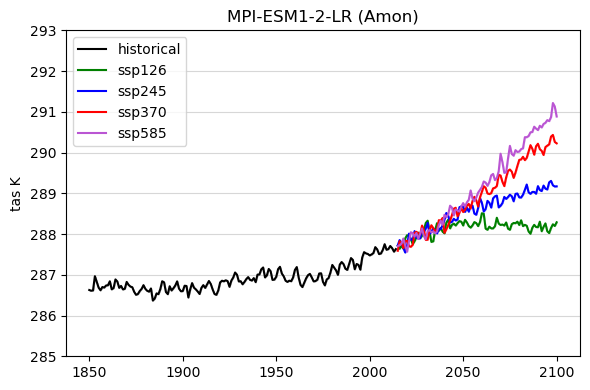

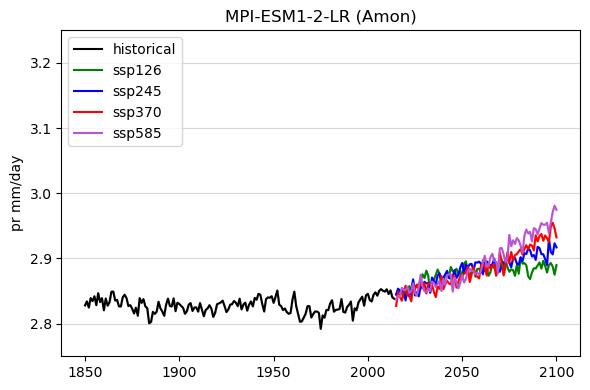

In [4]:
root_path = '/gpfs-calypso/scratch/globc/garcia/scenarIA/rawdata/MPI-ESM1-2-LR/mon/'
files_dict = {}

for var in ['tas', 'pr']:

    for exp in labels:
        exp_paths = glob.glob(root_path + f'{exp}/{var}_Amon_MPI-ESM1-2-LR_{exp}_r1i1p1f1_gn_*.nc')
        files_dict[exp] = exp_paths
    print(files_dict)

    plot_mean_std_simulations(files_dict,
                              var_name = var,
                              colors_dict = colors_dict,
                              time_res = 'm',
                              title='MPI-ESM1-2-LR (Amon)',
                              vmin=vmin[var],
                              vmax=vmax[var],
                              save_path=GRAPHS_DIR / f'tests/MPI-ESM1-2-LR_Amon_{var}_temporal_evolution.png'
                              )